In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import os
from typing import Dict
import pickle
from scipy.stats import linregress


def set_default_plot_style():
    plt.style.use("default")  # start clean

    plt.rcParams["axes.grid"] = True
    plt.rcParams["grid.alpha"] = 0.2
    plt.rcParams["grid.linestyle"] = "-"
    plt.rcParams["grid.color"] = "gray"

    plt.rcParams["axes.spines.top"] = False
    plt.rcParams["axes.spines.right"] = False

    plt.rcParams["axes.linewidth"] = 1.2

    plt.rcParams["legend.frameon"] = False

    plt.rcParams["font.size"] = 16
    plt.rcParams["axes.labelsize"] = 24
    plt.rcParams["legend.fontsize"] = 18

    mpl.rcParams['text.usetex'] = True
    mpl.rcParams['font.family'] = 'serif'
    mpl.rcParams['font.serif'] = ['Computer Modern Roman']

# Call once at the top of your script
set_default_plot_style()


In [2]:
# Helpful funcs
def log_b(x, b):
    return np.log(x) / np.log(b)


In [3]:
L_vals = [3000, 6000, 12000, 24000]

epdilon_vals = [0.26779]
delta_val = 0.2
delta_val_name = f"{delta_val}".replace(".", "p")

time_prefact = 10000

num_initial_conds = 3999
initial_state_prob = 0.5

time_step = 150000

cmap = plt.colormaps.get_cmap("Oranges").resampled(len(epdilon_vals) + 5)
cmap2 = plt.colormaps.get_cmap("Blues").resampled(len(L_vals) + 5)


read_external_drive = True
write_external_drive = read_external_drive and True
local_data_parent_folder = "data"
if read_external_drive:
    data_parent_folder = "/Volumes/ExternalData/stavskya_mc/data"
    if write_external_drive:
        local_data_parent_folder = "/Volumes/ExternalData/stavskya_mc/data"
else:
    data_parent_folder = local_data_parent_folder


In [4]:
# If first time

collected_rhos = {}
collected_rho_stds = {}

for L_val in L_vals:
    print(f"L_val: {L_val}")

    T_f = L_val*time_prefact
    collected_rhos[L_val] = {}
    collected_rho_stds[L_val] = {}

    for epdilon in epdilon_vals:
        print(f"L_val: {L_val} | epsilon: {epdilon}")
        epsilon_val_name = f"{epdilon}".replace(".", "p")

        current_rhos = np.array([[0.0 for _ in range(L_val * time_prefact // time_step)] for _ in range(num_initial_conds)])
        for init_cond in range(1, num_initial_conds+1):
            sample_filepath_name = os.path.join(data_parent_folder, f"time_rand_delta/rho_per_time/IC1/L{L_val}/delta{delta_val_name}/epsilon{epsilon_val_name}/IC1_L{L_val}_epsilon{epsilon_val_name}_timepref{time_prefact}_timestep{time_step}_sample{init_cond}.csv")
            try:
                df = pd.read_csv(sample_filepath_name)

                current_rhos[init_cond-1] = df.rho
            except Exception as e:
                print(e)
                print(sample_filepath_name)
        
        collected_rhos[L_val][epdilon] = np.mean(current_rhos.T, axis=1)
        collected_rho_stds[L_val][epdilon] = np.std(current_rhos.T, axis=1)

        pickle_path = os.path.join(local_data_parent_folder, f"time_rand_delta/rho_per_time/IC1/L{L_val}/delta{delta_val_name}/epsilon{epsilon_val_name}/IC1_L{L_val}_epsilon{epsilon_val_name}_timepref{time_prefact}_timestep{time_step}")
        dir_path = os.path.dirname(pickle_path)
        os.makedirs(dir_path, exist_ok=True)
        
        with open(pickle_path + "mean.pickle", "wb") as f:
            pickle.dump(collected_rhos[L_val][epdilon], f)
        with open(pickle_path + "stds.pickle", "wb") as f:
            pickle.dump(collected_rho_stds[L_val][epdilon], f)

L_val: 3000
L_val: 3000 | epsilon: 0.26779
[Errno 2] No such file or directory: '/Volumes/ExternalData/stavskya_mc/data/time_rand_delta/rho_per_time/IC1/L3000/delta0p2/epsilon0p26779/IC1_L3000_epsilon0p26779_timepref10000_timestep150000_sample1.csv'
/Volumes/ExternalData/stavskya_mc/data/time_rand_delta/rho_per_time/IC1/L3000/delta0p2/epsilon0p26779/IC1_L3000_epsilon0p26779_timepref10000_timestep150000_sample1.csv
[Errno 2] No such file or directory: '/Volumes/ExternalData/stavskya_mc/data/time_rand_delta/rho_per_time/IC1/L3000/delta0p2/epsilon0p26779/IC1_L3000_epsilon0p26779_timepref10000_timestep150000_sample2.csv'
/Volumes/ExternalData/stavskya_mc/data/time_rand_delta/rho_per_time/IC1/L3000/delta0p2/epsilon0p26779/IC1_L3000_epsilon0p26779_timepref10000_timestep150000_sample2.csv
[Errno 2] No such file or directory: '/Volumes/ExternalData/stavskya_mc/data/time_rand_delta/rho_per_time/IC1/L3000/delta0p2/epsilon0p26779/IC1_L3000_epsilon0p26779_timepref10000_timestep150000_sample3.csv'


PermissionError: [Errno 13] Permission denied: '/Volumes/ExternalData'

In [ ]:

collected_rhos = {}
collected_rho_stds = {}

for L_val in L_vals:
    print(f"L_val: {L_val}")

    T_f = L_val*time_prefact
    collected_rhos[L_val] = {}
    collected_rho_stds[L_val] = {}

    collected_rhos[L_val] = {}
    collected_rho_stds[L_val] = {}
    for epdilon in epdilon_vals:
        epsilon_val_name = f"{epdilon}".replace(".", "p")
        pickle_path = os.path.join(local_data_parent_folder, f"time_rand_delta/rho_per_time/IC1/L{L_val}/delta{delta_val_name}/epsilon{epsilon_val_name}/IC1_L{L_val}_epsilon{epsilon_val_name}_timepref{time_prefact}_timestep{time_step}")
        
        with open(pickle_path + "mean.pickle", "rb") as f:
            collected_rhos[L_val][epdilon] = pickle.load(f)
        with open(pickle_path + "stds.pickle", "rb") as f:
            collected_rho_stds[L_val][epdilon] = pickle.load(f)

L_val: 1500
L_val: 3000
L_val: 6000
L_val: 12000
L_val: 24000


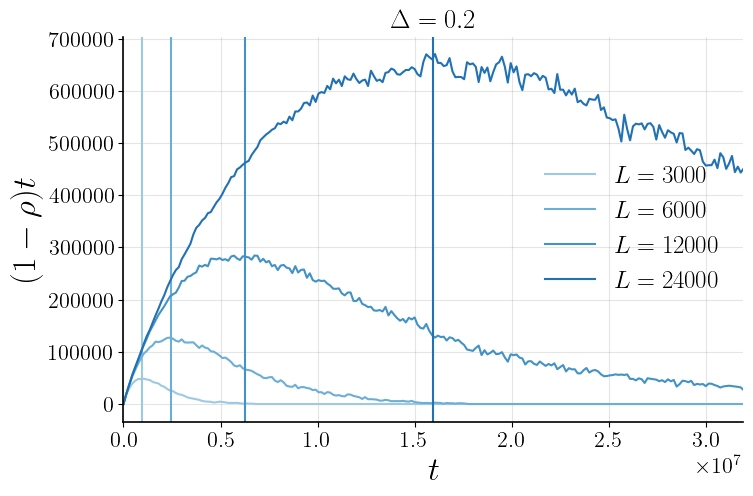

In [ ]:
epsilon_c = 0.26779
z_guess = 1.35
found_delta = 0.13

C = 19.5

plt.figure(figsize=(8,5))
for j, L in enumerate(L_vals):
    c = cmap2(j+3)
    time_vals = np.array([i * time_step for i in range(0, round(L*time_prefact / time_step))])
    orig_data = 1-collected_rhos[L][epsilon_c]
    plt.plot(
        (time_vals)[0::], 
        (orig_data * time_vals)[0::], 
        label = fr"$L = {L}$",
        # fmt='--',  
        # markersize=3,
        # marker = "o",
        # capsize=3,
        c=c
        )
    plt.axvline(C * L ** z_guess, c=c)

plt.xlabel(r"$t$")
plt.ylabel(r"$(1 - \rho)t$")
plt.legend()
plt.title(fr"$\Delta = {delta_val}$")
plt.xlim(0, 2 * C * max(L_vals)**z_guess)
# plt.ylim(0.7, 0.77)

plt.show()

/var/folders/0k/n4x5z88x1rx124p1g1l55hmc0000gn/T/ipykernel_2171/1934818503.py:11: RuntimeWarning: divide by zero encountered in log10
  np.log10((time_vals/(L ** z_guess)))[0::],
/var/folders/0k/n4x5z88x1rx124p1g1l55hmc0000gn/T/ipykernel_2171/1934818503.py:12: RuntimeWarning: divide by zero encountered in log10
  np.log10((orig_data * time_vals ** found_delta))[0::],


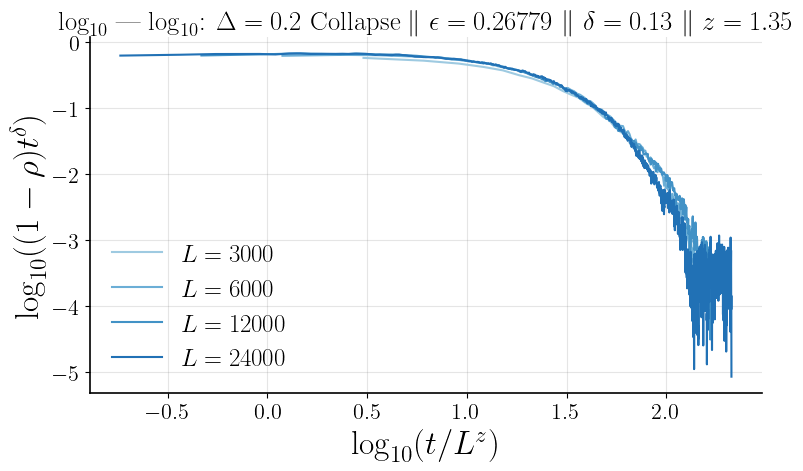

In [ ]:
epsilon_c = 0.26779
z_guess = 1.35
found_delta = 0.13

plt.figure(figsize=(8,5))
for j, L in enumerate(L_vals):
    c = cmap2(j+3)
    time_vals = np.array([i * time_step for i in range(0, round(L*time_prefact / time_step))])
    orig_data = 1-collected_rhos[L][epsilon_c]
    plt.plot(
        np.log10((time_vals/(L ** z_guess)))[0::], 
        np.log10((orig_data * time_vals ** found_delta))[0::], 
        label = fr"$L = {L}$",
        # fmt='--',  
        # markersize=3,
        # marker = "o",
        # capsize=3,
        c=c
        )

# plt.axvline(0.29450750, c = 'k', label=f"x = 0.29450750 (old trans)")
plt.title(fr"$\log_{{10}}$ | $\log_{{10}}$: $\Delta = {delta_val}$ Collapse $\|$ $\epsilon = {epsilon_c}$ $\|$ $\delta = {found_delta}$ $\|$ $z = {z_guess}$")
plt.xlabel(r"$\log_{10}(t/L^z)$")
plt.ylabel(r"$\log_{10}((1 - \rho)t^\delta)$")
plt.legend()
# plt.xlim(2.0, 2.25)
# plt.ylim(0.7, 0.77)
plt.tight_layout()
plt.savefig(f"figs/time_random/delta{delta_val_name}/fss_z_estimate.png")
plt.show()

/var/folders/0k/n4x5z88x1rx124p1g1l55hmc0000gn/T/ipykernel_2171/1139973769.py:7: RuntimeWarning: divide by zero encountered in log10
  np.log10(time_vals)[1::],
/var/folders/0k/n4x5z88x1rx124p1g1l55hmc0000gn/T/ipykernel_2171/1139973769.py:8: RuntimeWarning: divide by zero encountered in log10
  np.log10((orig_data))[1::],


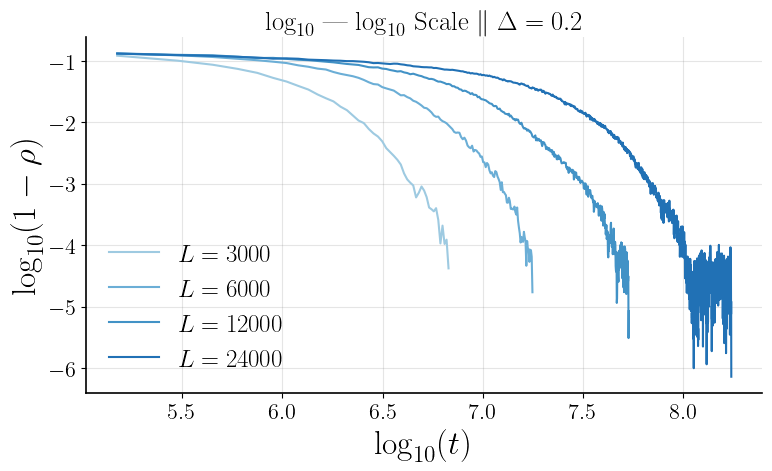

In [26]:

plt.figure(figsize=(8,5))
for j, L in enumerate(L_vals):
    c = cmap2(j+3)
    time_vals = np.array([i * time_step for i in range(0, L*time_prefact // time_step)])
    orig_data = 1-collected_rhos[L][epsilon_c]
    plt.plot(
        np.log10(time_vals)[1::], 
        np.log10((orig_data))[1::], 
        label = fr"$L = {L}$",
        # fmt='--',  
        # markersize=3,
        # marker = "o",
        # capsize=3,
        c=c
        )

# plt.axvline(0.29450750, c = 'k', label=f"x = 0.29450750 (old trans)")
plt.title(fr"$\log_{{10}}$ | $\log_{{10}}$ Scale $\|$ $\Delta = {delta_val}$")
plt.xlabel(r"$\log_{10}(t)$")
plt.ylabel(r"$\log_{10}(1 - \rho)$")
plt.legend()
# plt.xlim(np.log10(0.001), np.log10(1))
# plt.ylim(0.7, 0.77)
plt.tight_layout()
plt.savefig(f"figs/time_random/delta{delta_val_name}/z_estimate.png")

plt.show()

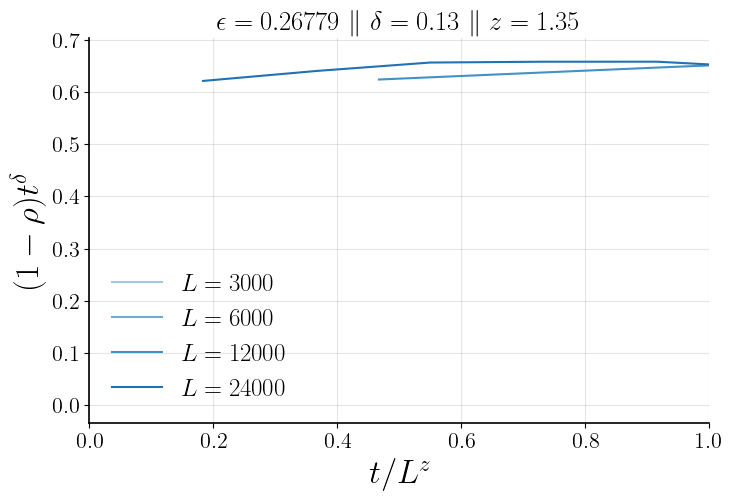

In [32]:
epsilon_c = 0.26779
z_guess = 1.35
found_delta = 0.13

plt.figure(figsize=(8,5))
for j, L in enumerate(L_vals):
    c = cmap2(j+3)
    time_vals = np.array([i * time_step for i in range(0, L*time_prefact // time_step)])
    orig_data = 1-collected_rhos[L][epsilon_c]
    plt.plot(
        (time_vals / (L**z_guess))[1::], 
        (orig_data * time_vals ** found_delta)[1::], 
        label = fr"$L = {L}$",
        # fmt='--',  
        # markersize=3,
        # marker = "o",
        # capsize=3,
        c=c
        )

# plt.axvline(0.29450750, c = 'k', label=f"x = 0.29450750 (old trans)")
plt.title(fr"$\epsilon = {epsilon_c}$ $\|$ $\delta = {found_delta}$ $\|$ $z = {z_guess}$")
plt.xlabel(r"$t/L^z$")
plt.ylabel(r"$(1 - \rho)t^\delta$")
plt.legend()
plt.xlim(0, 1)
# plt.ylim(0.7, 0.77)

plt.show()